<a href="https://colab.research.google.com/github/shivamrahane/regression-model-newyork-taxi-dataset/blob/main/Regularized_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <b><u>Regularization</b>

### Before discussing about regularization, we'll do a quick recap on the notion of **overfitting** and the **bias-variance tradeoff**.

### <u>**Overfitting:**</u> So what is overfitting? Well, to put it in more simple terms it's when we built a model that is too complex that it matches the training data "too closely" or we can say that the model has started to learn not only the signal, but also the noise in the data. The result of this is that our model will do well on the training data, but won't generalize to out-of-sample data, data that we have not seen before.

### <u>**Bias-Variance tradeoff:** </u>When we discuss prediction models, prediction errors can be decomposed into two main subcomponents we care about: error due to "bias" and error due to "variance". Understanding these two types of error can help us diagnose model results and avoid the mistake of over/under fitting. A typical graph of discussing this is shown below:

- ### **Bias:** The red line, measures how far off in general our models' predictions are from the correct value. Thus as our model gets more and more complex we will become more and more accurate about our predictions (Error steadily decreases).
- ### **Variance:** The cyan line, measures how different can our model be from one to another, as we're looking at different possible data sets. If the estimated model will vary dramatically from one data set to the other, then we will have very erratic predictions, because our prediction will be extremely sensitive to what data set we obtain. As the complexity of our model rises, variance becomes our primary concern.

### When creating a model, our goal is to locate the optimum model complexity. If our model complexity exceeds this sweet spot, we are in effect overfitting our model; while if our complexity falls short of the sweet spot, we are underfitting the model. With all of that in mind, the notion of **regularization** is simply a useful technique to use when we think our model is too complex (models that have low bias, but high variance). It is a method for "constraining" or "regularizing" the **size of the coefficients** ("shrinking" them towards zero). The specific regularization techniques we'll be discussing are **Ridge Regression** and **Lasso Regression**.

# <b> <u>Ridge and Lasso Regression </b>

### Regularized linear regression models are very similar to least squares, except that the coefficients are estimated by minimizing a slightly different objective function. we **minimize the sum of RSS and a "penalty term"** that penalizes coefficient size.

### **Ridge regression** (or "L2 regularization") minimizes:

$$\text{RSS} + \lambda \sum_{j=1}^p \beta_j^2$$

### **Lasso regression** (or "L1 regularization") minimizes:

$$\text{RSS} + \lambda \sum_{j=1}^p \lvert \beta_j \rvert$$

### Where $\lambda$ is a **tuning parameter** that seeks to balance between the fit of the model to the data and the magnitude of the model's coefficients:

- ### A tiny $\lambda$ imposes no penalty on the coefficient size, and is equivalent to a normal linear regression.
- ### Increasing $\lambda$ penalizes the coefficients and thus shrinks them towards zero.

### <b>Lasso stands for least absolute shrinkage and selection operator</b>

### Thus you can think of it as, we're balancing two things to measure the model's total quality. The RSS, measures how well the model is going to fit the data, and then the magnitude of the coefficients, which can be problematic if they become too big.


- ### **Lasso regression** shrinks coefficients all the way to zero, thus removing them from the model.
- ### **Ridge regression** shrinks coefficients toward zero, but they rarely reach zero.

### To get a sense of why this is happening, the visualization below depicts what happens when we apply the two different regularization. The general idea is that we are restricting the allowed values of our coefficients to a certain "region" and within that region, we wish to find the coefficients that result in the best model.


### In this diagram, we are fitting a linear regression model with two features, $x_1$ and $x_2$.

- ### $\hat\beta$ represents the set of two coefficients, $\beta_1$ and $\beta_2$, which minimize the RSS for the **unregularized model**.
- ### The ellipses that are centered around $\hat\beta$ represent **regions of constant RSS**. In other words, all of the points on a given ellipse share a common value of the RSS, despite the fact that they may have different values for $\beta_1$ and $\beta_2$. As the ellipses expand away from the least squares coefficient estimates, the RSS increases.
- ### Regularization restricts the allowed positions of $\hat\beta$ to the **blue constraint region**. In this case, $\hat\beta$ is **not** within the blue constraint region. Thus, we need to move $\hat\beta$ until it intersects the blue region, while increasing the RSS as little as possible.
- ### For **ridge**, this region is a **circle** because it constrains the square of the coefficients. Thus the intersection will not generally occur on an axis, and so the coefficient estimates will be typically be non-zero.
- ### For **lasso**, this region is a **diamond** because it constrains the absolute value of the coefficients. Because the constraint has corners at each of the axes, and so the ellipse will often intersect the constraint region at an axis. When this occurs, one of the coefficients will equal zero. In higher dimensions, many of the coefficient estimates may equal zero simultaneously. In the figure above, the intersection occurs at $\beta_1 = 0$, and so the resulting model will only include $\beta_2$.
- ### The **size of the blue constraint region** is determined by $\lambda$, with a smaller $\lambda$ resulting in a larger region:
- #### When $\lambda$ is zero, the blue region is infinitely large, and thus the coefficient sizes are not constrained.
- ### When $\lambda$ increases, the blue region gets smaller and smaller.

# <b><u> Let us do some Python implementation of these two regularized linear regressions

### Let us load the Boston Housing Dataset, which contains some dataset about the housing values in suburbs of Boston. We'll choose the first few features, train a ridge and lasso regression separately at look at the estimated coefficients' weight for different $\lambda$ parameter.

### Note that we're choosing the first few features

# Linear Regression Practical Implementation

In [ ]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')

In [ ]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


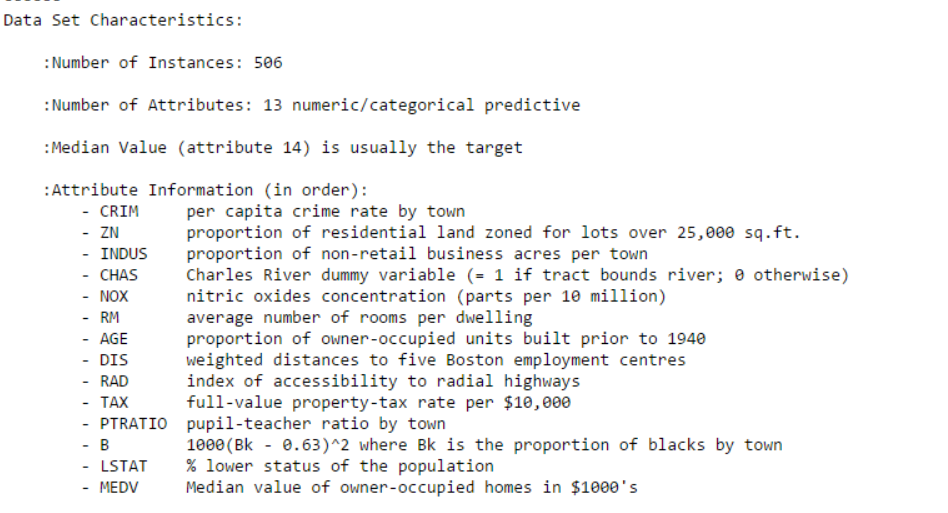

**Independent features and dependent features**

In [ ]:
df.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

In [ ]:
x = df.drop('medv',axis=1)
y = df['medv']

In [ ]:
x

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48


In [ ]:
import seaborn as sns

In [ ]:
numeric_features = df.describe().columns
numeric_features

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

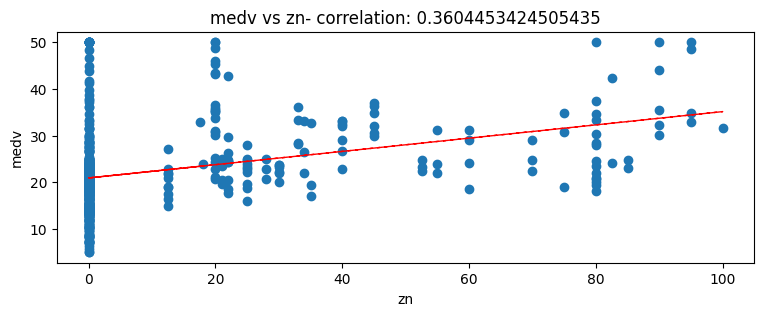

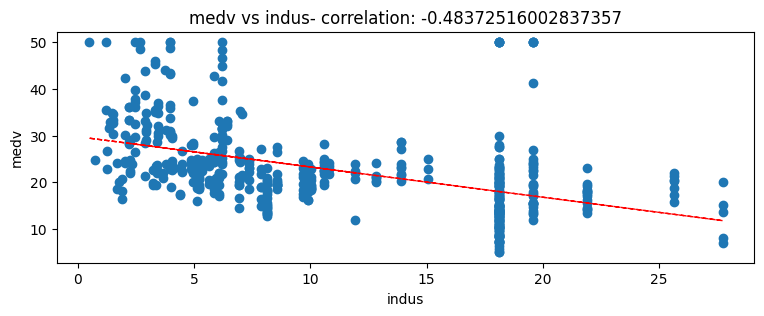

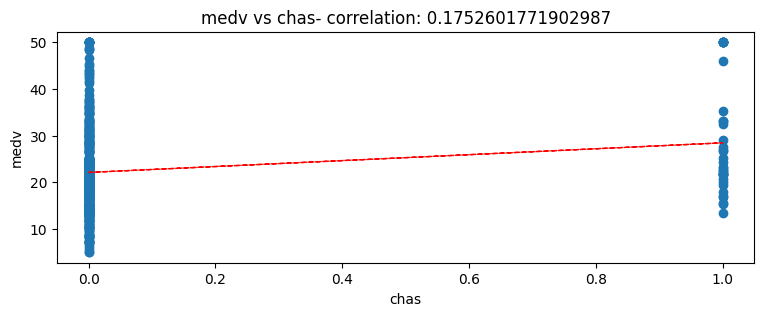

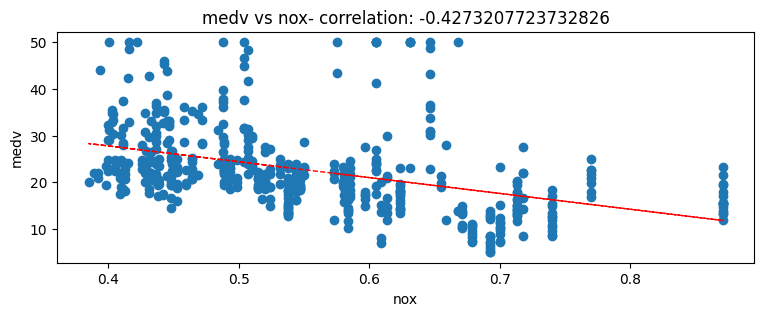

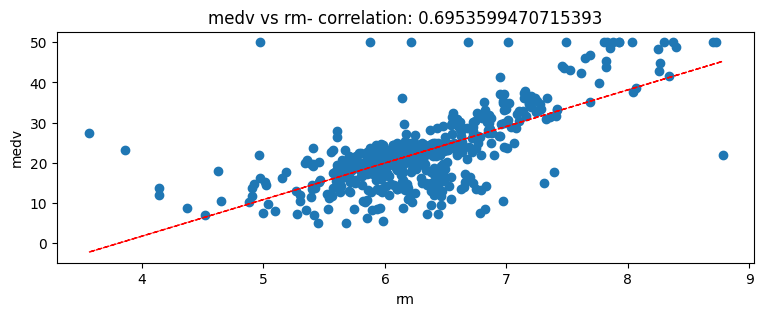

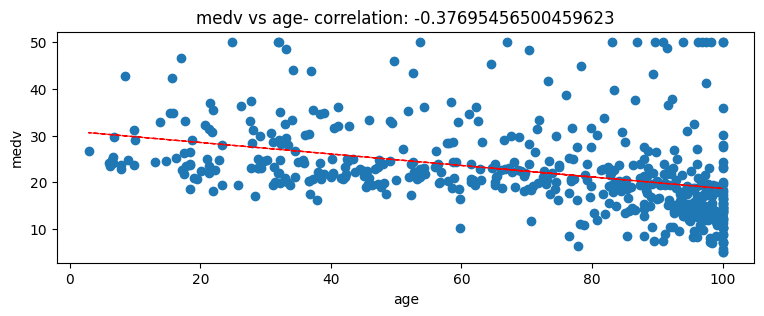

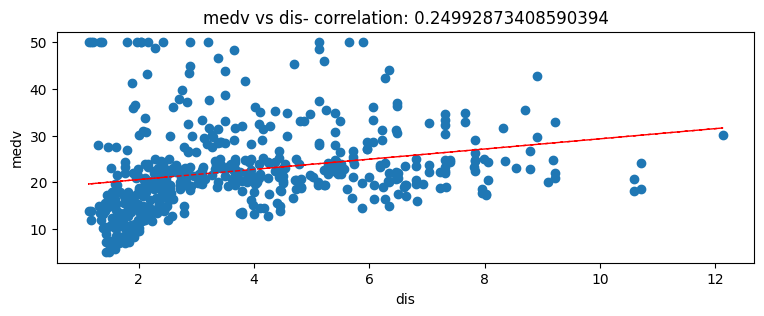

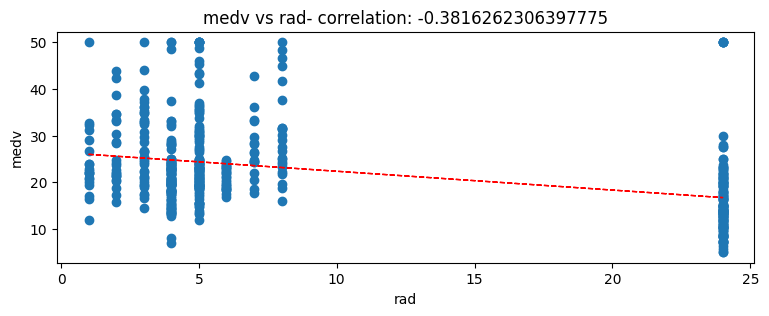

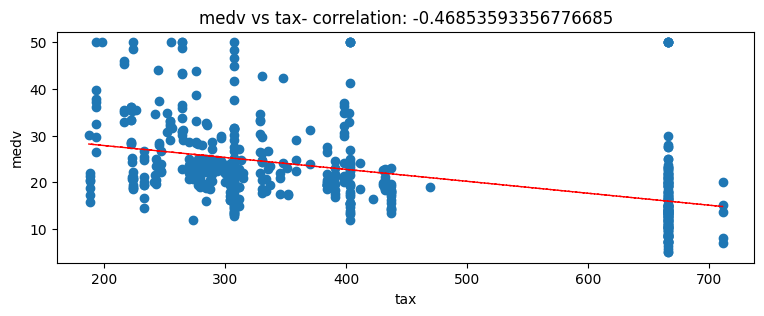

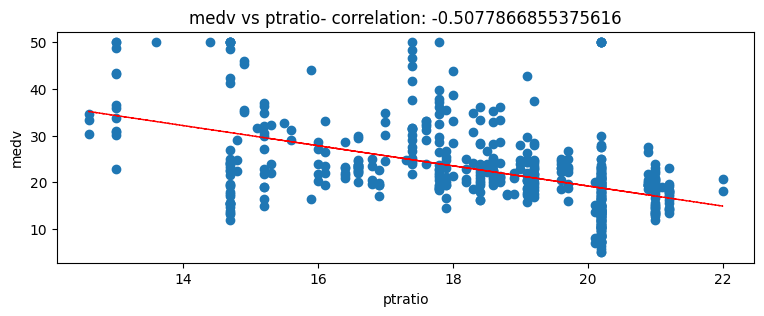

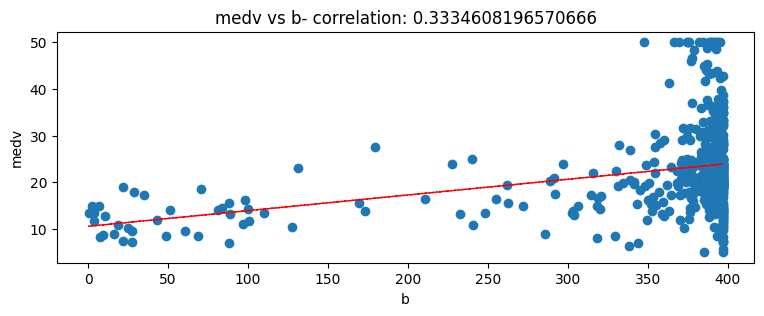

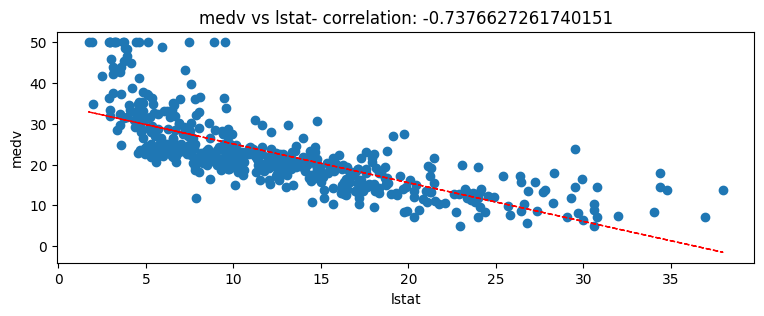

In [ ]:
for col in numeric_features[1:-1]:
    fig = plt.figure(figsize=(9, 3))
    ax = fig.gca()
    feature = df[col]
    label = df['medv']
    correlation = feature.corr(label)
    plt.scatter(x=feature, y=label)
    plt.xlabel(col)
    plt.ylabel('medv')
    ax.set_title('medv vs ' + col + '- correlation: ' + str(correlation))
    z = np.polyfit(df[col], df['medv'], 1)
    y_hat = np.poly1d(z)(df[col])

    plt.plot(df[col], y_hat, "r--", lw=1)

plt.show()

<Axes: >

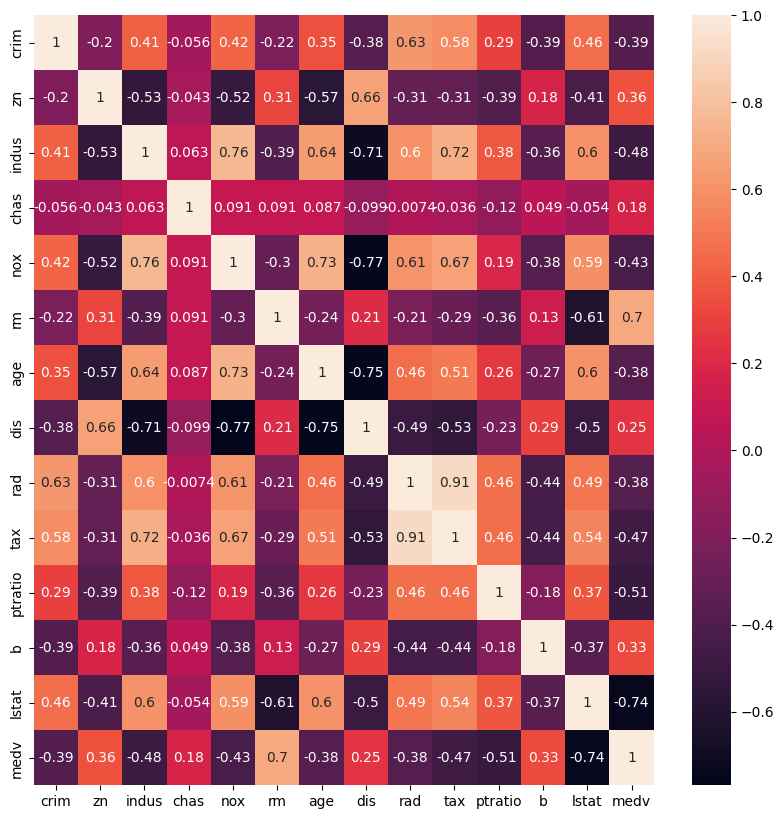

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True)

In [ ]:
y

,medv
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2
...,...
501,22.4
502,20.6
503,23.9
504,22.0


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
df.shape

(506, 14)

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.10,random_state=42)

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(455, 13)
(51, 13)
(455,)
(51,)


In [ ]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler

In [ ]:
scaler = RobustScaler()

In [ ]:
x_train_scal = scaler.fit_transform(x_train)
x_test_scal = scaler.transform(x_test)

**cross validation & Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()
model.fit(x_train_scal,y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score, mean_absolute_error


In [ ]:
train_pred = model.predict(x_train_scal)
print(f'train Mean Absolute Percentage Error :- {mean_absolute_percentage_error(train_pred,y_train)}')
print(f'train Mean Absolute Error :- {mean_absolute_error(train_pred,y_train)}')
print(f'train Root Mean Squared Error :- {np.sqrt(mean_squared_error(train_pred,y_train))}')
print(f'train R2 Score :- {r2_score(train_pred,y_train)}')
print('')
print('')
print('**************************************************************************************')
test_pred = model.predict(x_test_scal)
print(f'test Mean Absolute Percentage Error :- {mean_absolute_percentage_error(test_pred,y_test)}')
print(f'test Mean Absolute Error :- {mean_absolute_error(test_pred,y_test)}')
print(f'test Root Mean Squared Error :- {np.sqrt(mean_squared_error(test_pred,y_test))}')
print(f'test R2 Score :- {r2_score(test_pred,y_test)}')

train Mean Absolute Percentage Error :- 0.260202044722269
train Mean Absolute Error :- 3.3602282598985878
train Root Mean Squared Error :- 4.768394924341586
train R2 Score :- 0.6440958775015275


**************************************************************************************
test Mean Absolute Percentage Error :- 0.16486050504625654
test Mean Absolute Error :- 2.8342104578589624
test Root Mean Squared Error :- 3.8724479178657343
test R2 Score :- 0.7545683007337268


In [ ]:
model.coef_

array([-0.42441775,  0.79826938,  0.27618124,  2.77565167, -3.32680378,
        2.79618685,  0.23013798, -4.80695335,  6.23756045, -4.56494776,
       -3.03218028,  0.21757613, -5.35243657])

# Ridge Regression Algorithm

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [ ]:
model = Ridge()

In [ ]:
model

Ridge()

In [ ]:
model.fit(x_train_scal,y_train)

Ridge()

In [ ]:
train_pred = model.predict(x_train_scal)
print(f'train Mean Absolute Percentage Error :- {mean_absolute_percentage_error(train_pred,y_train)}')
print(f'train Mean Absolute Error :- {mean_absolute_error(train_pred,y_train)}')
print(f'train Root Mean Squared Error :- {np.sqrt(mean_squared_error(train_pred,y_train))}')
print(f'train R2 Score :- {r2_score(train_pred,y_train)}')
print('')
print('')
print('**************************************************************************************')
test_pred = model.predict(x_test_scal)
print(f'test Mean Absolute Percentage Error :- {mean_absolute_percentage_error(test_pred,y_test)}')
print(f'test Mean Absolute Error :- {mean_absolute_error(test_pred,y_test)}')
print(f'test Root Mean Squared Error :- {np.sqrt(mean_squared_error(test_pred,y_test))}')
print(f'test R2 Score :- {r2_score(test_pred,y_test)}')

train Mean Absolute Percentage Error :- 0.2731054484800772
train Mean Absolute Error :- 3.348433656224681
train Root Mean Squared Error :- 4.770362709116716
train R2 Score :- 0.6404832082167344


**************************************************************************************
test Mean Absolute Percentage Error :- 0.16492399676475963
test Mean Absolute Error :- 2.822276626474151
test Root Mean Squared Error :- 3.8670020266351663
test R2 Score :- 0.751480123088832


## Hyper tuning

In [ ]:
parameters = {'alpha':[1,2,5,10,20,30,40,50,60,70,80,90]}
ridgecv = GridSearchCV(model,parameters,scoring='neg_mean_squared_error',cv=10)
ridgecv.fit(x_train_scal,y_train)

GridSearchCV(cv=10, estimator=Ridge(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80,
                                   90]},
             scoring='neg_mean_squared_error')

In [ ]:
train_pred = ridgecv.predict(x_train_scal)
print(f'train Mean Absolute Percentage Error :- {mean_absolute_percentage_error(train_pred,y_train)}')
print(f'train Mean Absolute Error :- {mean_absolute_error(train_pred,y_train)}')
print(f'train Root Mean Squared Error :- {np.sqrt(mean_squared_error(train_pred,y_train))}')
print(f'train R2 Score :- {r2_score(train_pred,y_train)}')
print('')
print('')
print('**************************************************************************************')
test_pred = ridgecv.predict(x_test_scal)
print(f'test Mean Absolute Percentage Error :- {mean_absolute_percentage_error(test_pred,y_test)}')
print(f'test Mean Absolute Error :- {mean_absolute_error(test_pred,y_test)}')
print(f'test Root Mean Squared Error :- {np.sqrt(mean_squared_error(test_pred,y_test))}')
print(f'test R2 Score :- {r2_score(test_pred,y_test)}')

train Mean Absolute Percentage Error :- 0.2731054484800772
train Mean Absolute Error :- 3.348433656224681
train Root Mean Squared Error :- 4.770362709116716
train R2 Score :- 0.6404832082167344


**************************************************************************************
test Mean Absolute Percentage Error :- 0.16492399676475963
test Mean Absolute Error :- 2.822276626474151
test Root Mean Squared Error :- 3.8670020266351663
test R2 Score :- 0.751480123088832


# Lasso Regression

In [ ]:
from sklearn.linear_model import Lasso

In [ ]:
lasso =Lasso()

In [ ]:
parameters = {'alpha':[1,2,5,10,20,30,40,50,60,70,80,90]}
lassocv = GridSearchCV(lasso,parameters,scoring='neg_root_mean_squared_log_error',cv=5)
lassocv.fit(x_train_scal,y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80,
                                   90]},
             scoring='neg_root_mean_squared_log_error')

In [ ]:
train_pred = lassocv.predict(x_train_scal)
print(f'train Mean Absolute Percentage Error :- {mean_absolute_percentage_error(train_pred,y_train)}')
print(f'train Mean Absolute Error :- {mean_absolute_error(train_pred,y_train)}')
print(f'train Root Mean Squared Error :- {np.sqrt(mean_squared_error(train_pred,y_train))}')
print(f'train R2 Score :- {r2_score(train_pred,y_train)}')
print('')
print('')
print('**************************************************************************************')
test_pred = lassocv.predict(x_test_scal)
print(f'test Mean Absolute Percentage Error :- {mean_absolute_percentage_error(test_pred,y_test)}')
print(f'test Mean Absolute Error :- {mean_absolute_error(test_pred,y_test)}')
print(f'test Root Mean Squared Error :- {np.sqrt(mean_squared_error(test_pred,y_test))}')
print(f'test R2 Score :- {r2_score(test_pred,y_test)}')

train Mean Absolute Percentage Error :- 0.20312219018247693
train Mean Absolute Error :- 4.33486851317609
train Root Mean Squared Error :- 6.178026916208688
train R2 Score :- -0.49546505067540614


**************************************************************************************
test Mean Absolute Percentage Error :- 0.2406565012289162
test Mean Absolute Error :- 3.800388074613914
test Root Mean Squared Error :- 5.15949928704368
test R2 Score :- -0.22129499021011823
